# Preços de Commodities - Investing.com via investpy

Preços diários de futuros de metais preciosos, metais base, minério de ferro, lítio, carvão, aço e urânio.

**Fonte:** Investing.com via investpy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

CUTOFF = '2021-03-01'
ZOOM_PERIOD = pd.DateOffset(years=1)  # período do zoom

# Output directory for figures (PNG 300 DPI — compatible with Google Docs)
FIG_DIR = Path('../figures/investpy')
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_PREFIX = 'investpy'

def save_fig(fig, name):
    """Save figure as high-res PNG with notebook prefix."""
    path = FIG_DIR / f'{FIG_PREFIX}_{name}.png'
    fig.savefig(path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f'  Saved: {path}')

In [2]:
df = pd.read_csv('../data/investpy/daily.csv', index_col=0, parse_dates=True)
df = df[df.index >= CUTOFF]
print(f'Dimensão: {df.shape} | {df.index.min().date()} a {df.index.max().date()}')
print(f'Colunas: {list(df.columns)}')

Dimensão: (1414, 15) | 2021-03-01 a 2026-03-27
Colunas: ['gold', 'copper', 'silver', 'aluminum', 'nickel', 'zinc', 'tin', 'lead', 'palladium', 'platinum', 'iron_ore_62fe', 'coal_newcastle', 'steel_hrc_china', 'uranium', 'lithium_lit']


## Metais Preciosos
Ouro, Prata, Platina e Paládio.

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/447258132.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_precious_gold.png


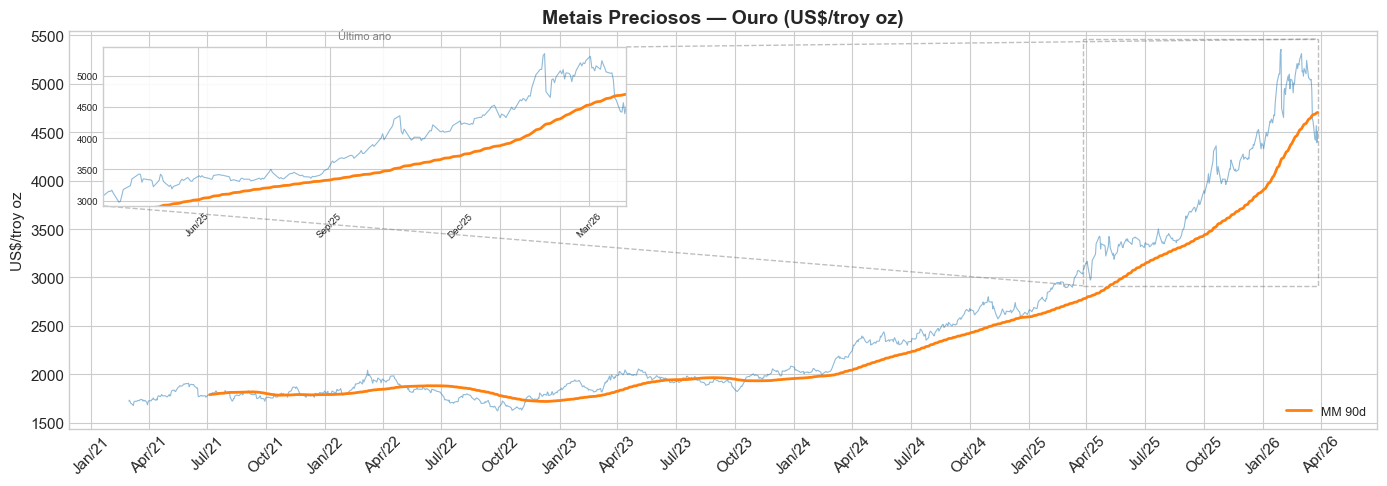

  Saved: ../figures/investpy/investpy_precious_silver.png


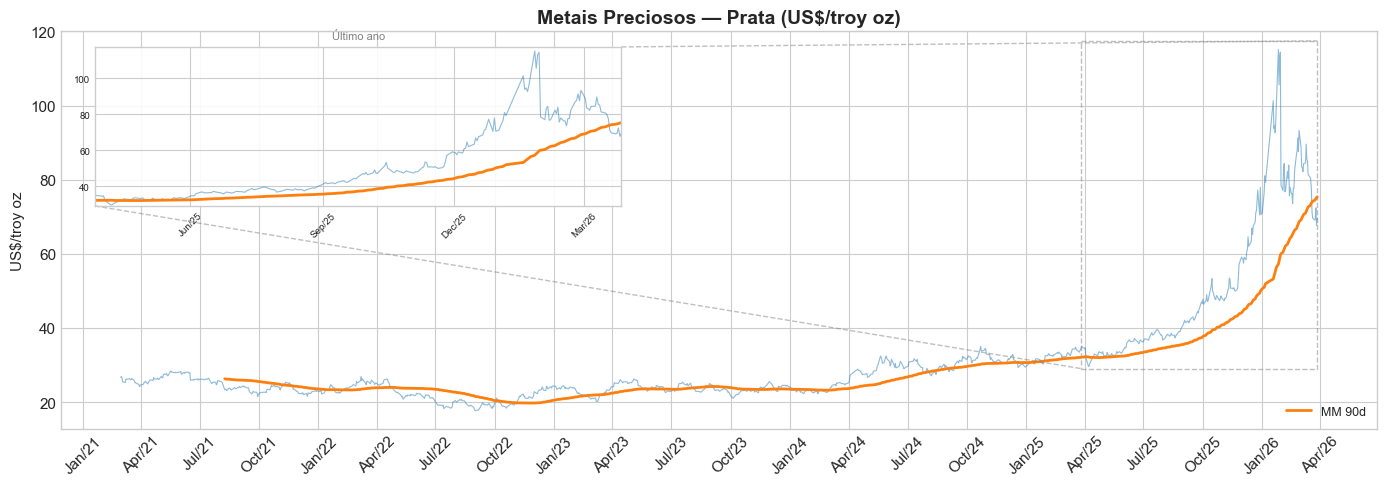

  Saved: ../figures/investpy/investpy_precious_platinum.png


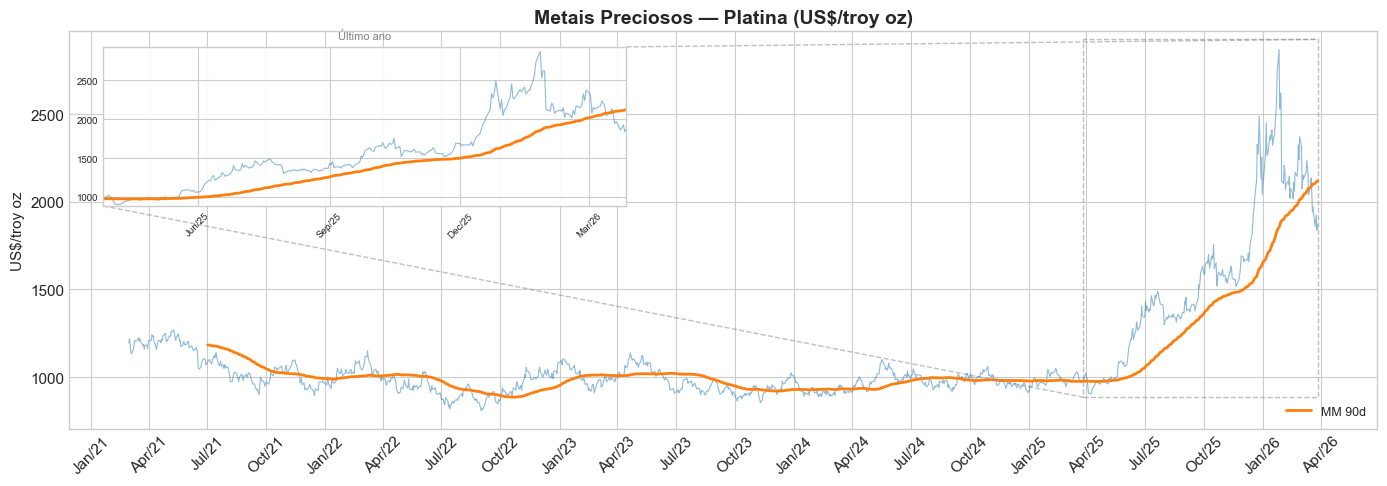

  Saved: ../figures/investpy/investpy_precious_palladium.png


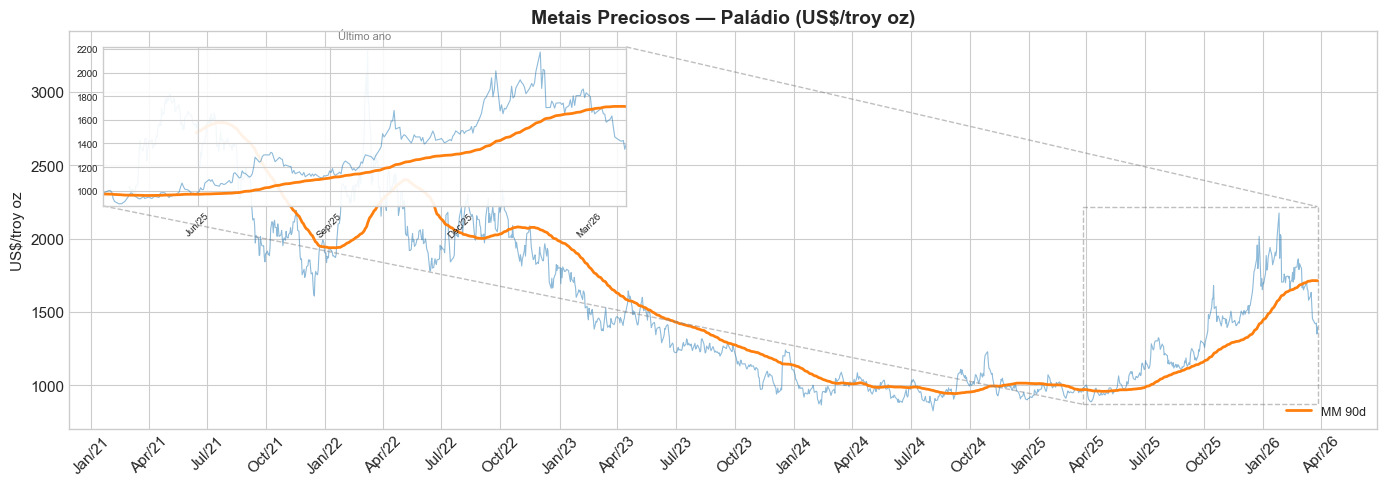

In [3]:
precious = [('gold', 'Ouro', 'US$/troy oz'), ('silver', 'Prata', 'US$/troy oz'),
            ('platinum', 'Platina', 'US$/troy oz'), ('palladium', 'Paládio', 'US$/troy oz')]
available = [(c, l, u) for c, l, u in precious if c in df.columns]
zoom_start = df.index.max() - ZOOM_PERIOD

for col, label, unit in available:
    fig, ax = plt.subplots(figsize=(14, 5))
    s = df[col].dropna()
    r90 = s.rolling(90).mean()
    ax.plot(s.index, s, alpha=0.5, linewidth=0.8, color='#1f77b4')
    ax.plot(s.index, r90, linewidth=2, color='#ff7f0e', label='MM 90d')
    ax.set_title(f'Metais Preciosos — {label} ({unit})', fontsize=14, fontweight='bold')
    ax.set_ylabel(unit)
    ax.legend(fontsize=9, loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=45)
    # Zoom inset - último ano
    axins = inset_axes(ax, width='40%', height='40%', loc='upper left',
                       bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
    sz = s[s.index >= zoom_start]
    rz = r90[r90.index >= zoom_start]
    axins.plot(sz.index, sz, alpha=0.5, linewidth=0.8, color='#1f77b4')
    axins.plot(rz.index, rz, linewidth=2, color='#ff7f0e')
    axins.set_xlim(zoom_start, s.index.max())
    if len(sz) > 0:
        axins.set_ylim(sz.min() * 0.98, sz.max() * 1.02)
    axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axins.tick_params(axis='x', rotation=45, labelsize=7)
    axins.tick_params(axis='y', labelsize=7)
    axins.set_title('Último ano', fontsize=8, color='gray')
    axins.patch.set_alpha(0.9)
    mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)
    plt.tight_layout()
    save_fig(fig, f'precious_{col}')
    plt.show()

## Metais Base
Cobre, Alumínio, Níquel, Zinco, Estanho e Chumbo.

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/2044199113.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_base_copper.png


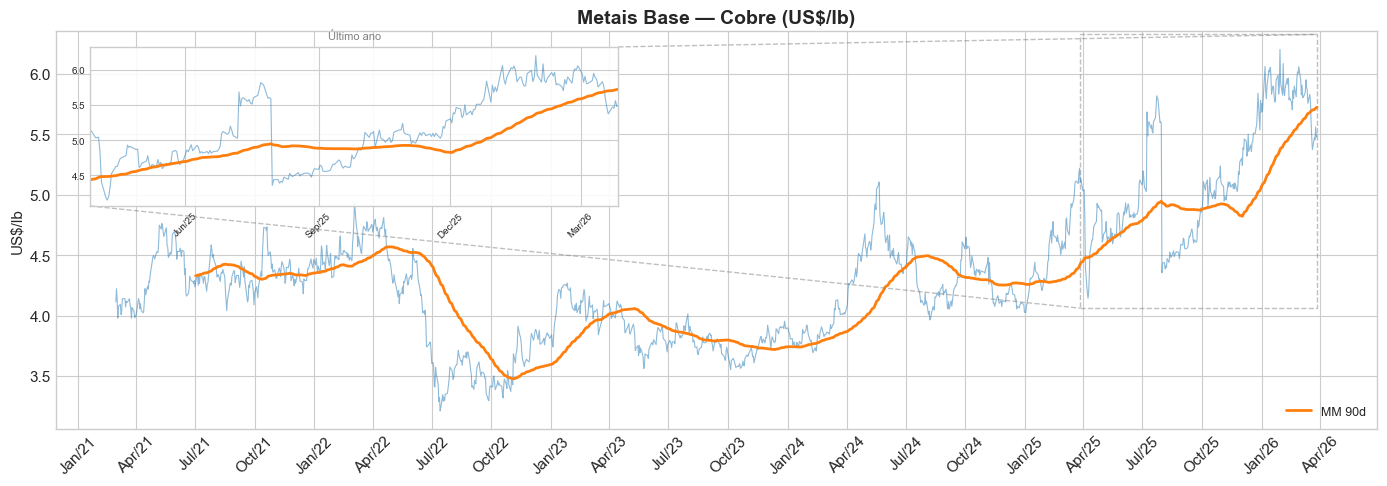

  Saved: ../figures/investpy/investpy_base_aluminum.png


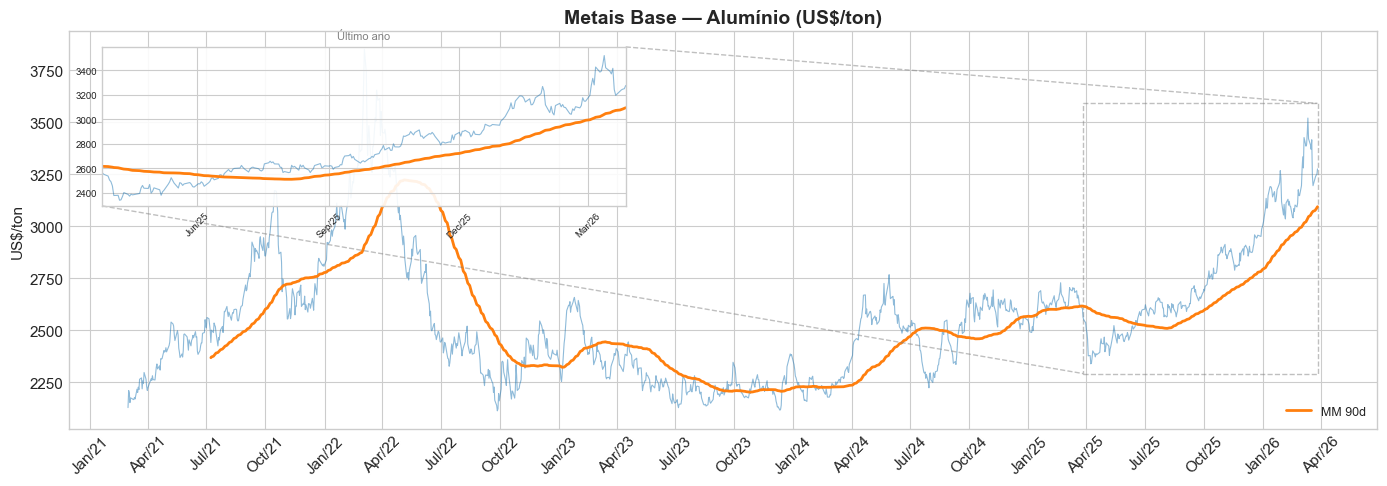

  Saved: ../figures/investpy/investpy_base_nickel.png


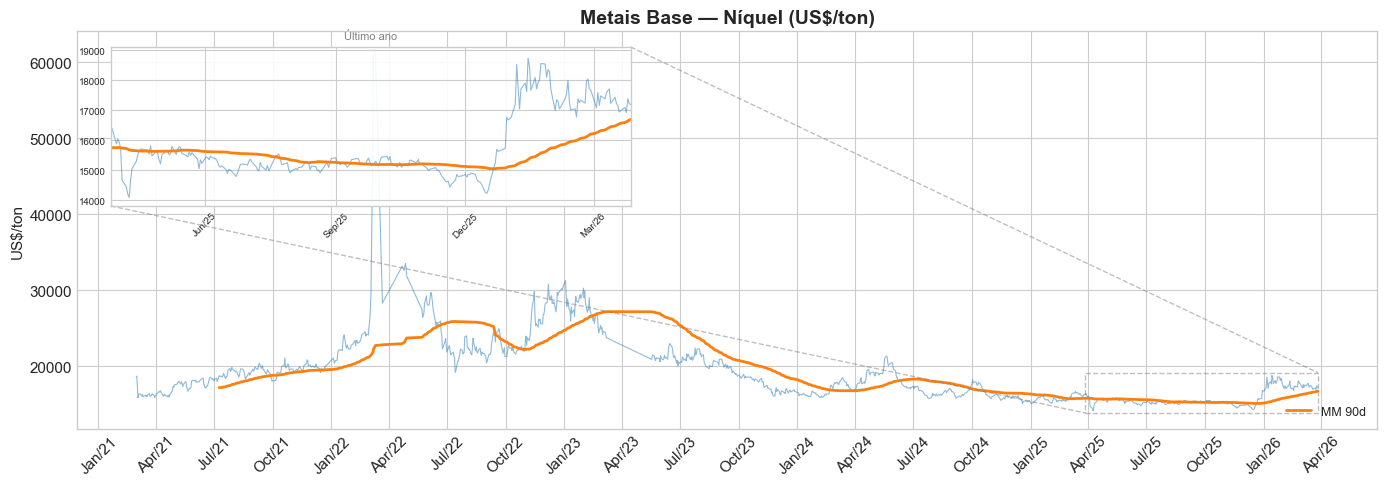

  Saved: ../figures/investpy/investpy_base_zinc.png


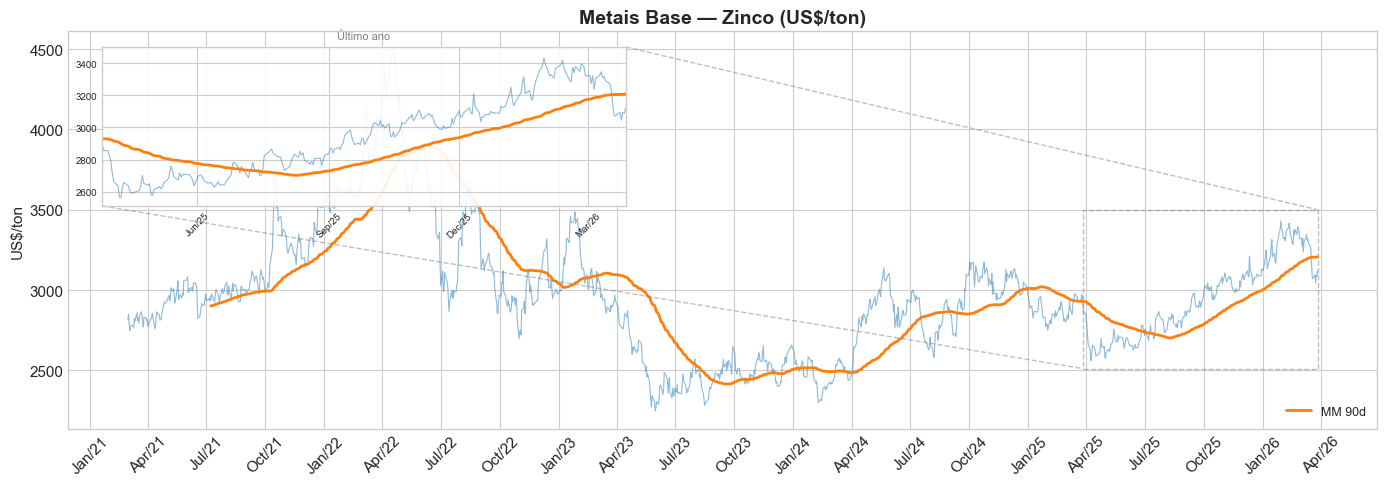

  Saved: ../figures/investpy/investpy_base_tin.png


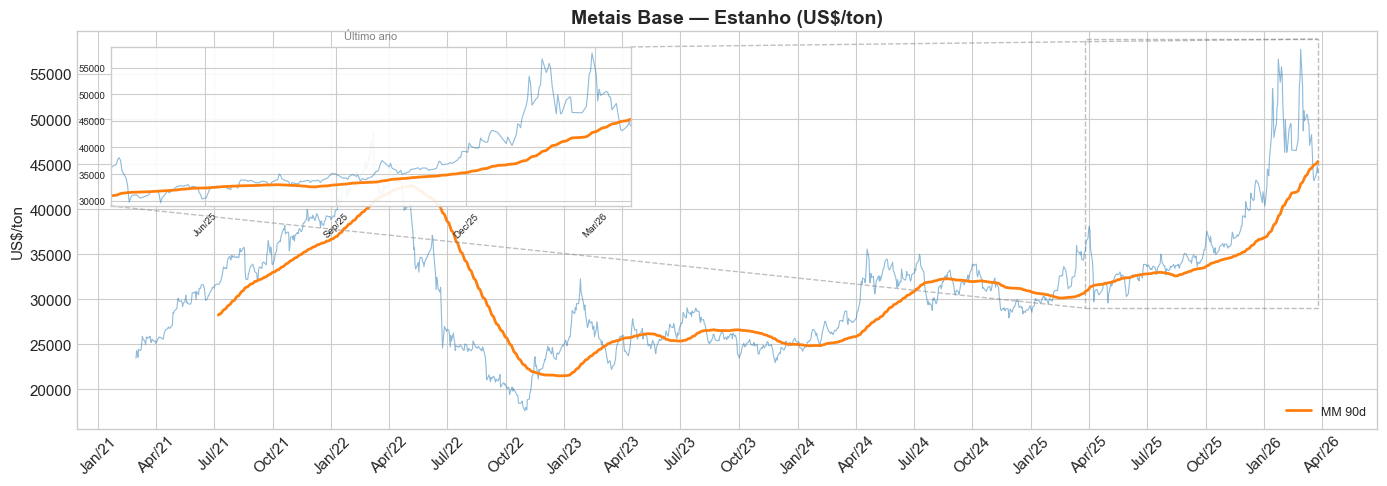

  Saved: ../figures/investpy/investpy_base_lead.png


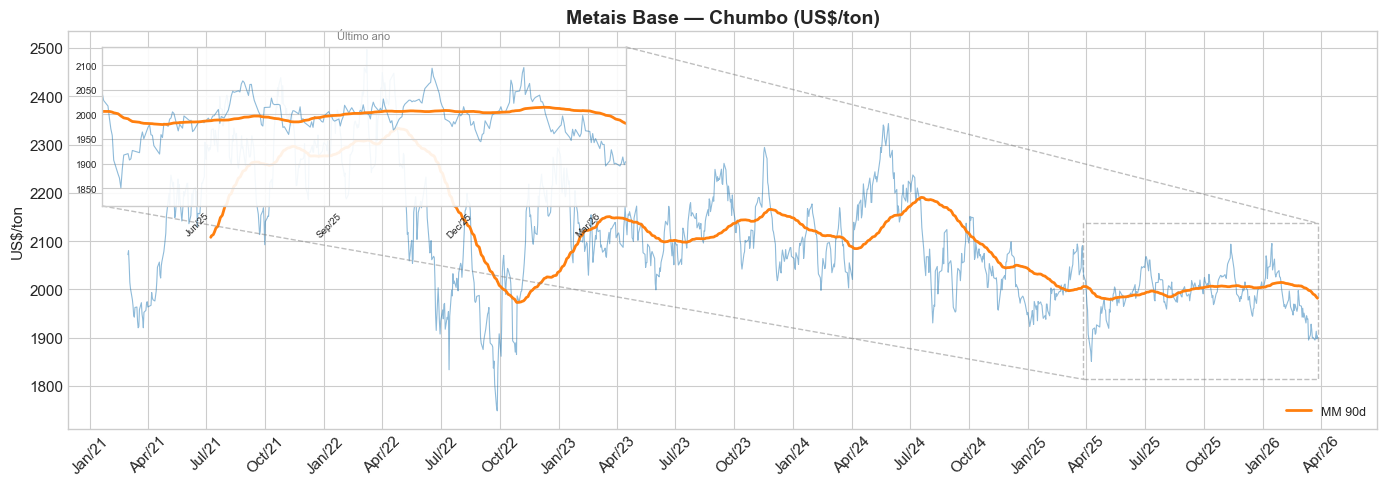

In [4]:
base_metals = [
    ('copper', 'Cobre', 'US$/lb'), ('aluminum', 'Alumínio', 'US$/ton'),
    ('nickel', 'Níquel', 'US$/ton'), ('zinc', 'Zinco', 'US$/ton'),
    ('tin', 'Estanho', 'US$/ton'), ('lead', 'Chumbo', 'US$/ton'),
]
zoom_start = df.index.max() - ZOOM_PERIOD

for col, label, unit in base_metals:
    if col not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(14, 5))
    s = df[col].dropna()
    r90 = s.rolling(90).mean()
    ax.plot(s.index, s, alpha=0.5, linewidth=0.8, color='#1f77b4')
    ax.plot(s.index, r90, linewidth=2, color='#ff7f0e', label='MM 90d')
    ax.set_title(f'Metais Base — {label} ({unit})', fontsize=14, fontweight='bold')
    ax.set_ylabel(unit)
    ax.legend(fontsize=9, loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=45)
    # Zoom inset - último ano
    axins = inset_axes(ax, width='40%', height='40%', loc='upper left',
                       bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
    sz = s[s.index >= zoom_start]
    rz = r90[r90.index >= zoom_start]
    axins.plot(sz.index, sz, alpha=0.5, linewidth=0.8, color='#1f77b4')
    axins.plot(rz.index, rz, linewidth=2, color='#ff7f0e')
    axins.set_xlim(zoom_start, s.index.max())
    if len(sz) > 0:
        axins.set_ylim(sz.min() * 0.98, sz.max() * 1.02)
    axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axins.tick_params(axis='x', rotation=45, labelsize=7)
    axins.tick_params(axis='y', labelsize=7)
    axins.set_title('Último ano', fontsize=8, color='gray')
    axins.patch.set_alpha(0.9)
    mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)
    plt.tight_layout()
    save_fig(fig, f'base_{col}')
    plt.show()

## Minério de Ferro 62% Fe CFR
Principal benchmark para minério de ferro no mercado internacional.

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/4204116784.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_iron_ore_detail.png


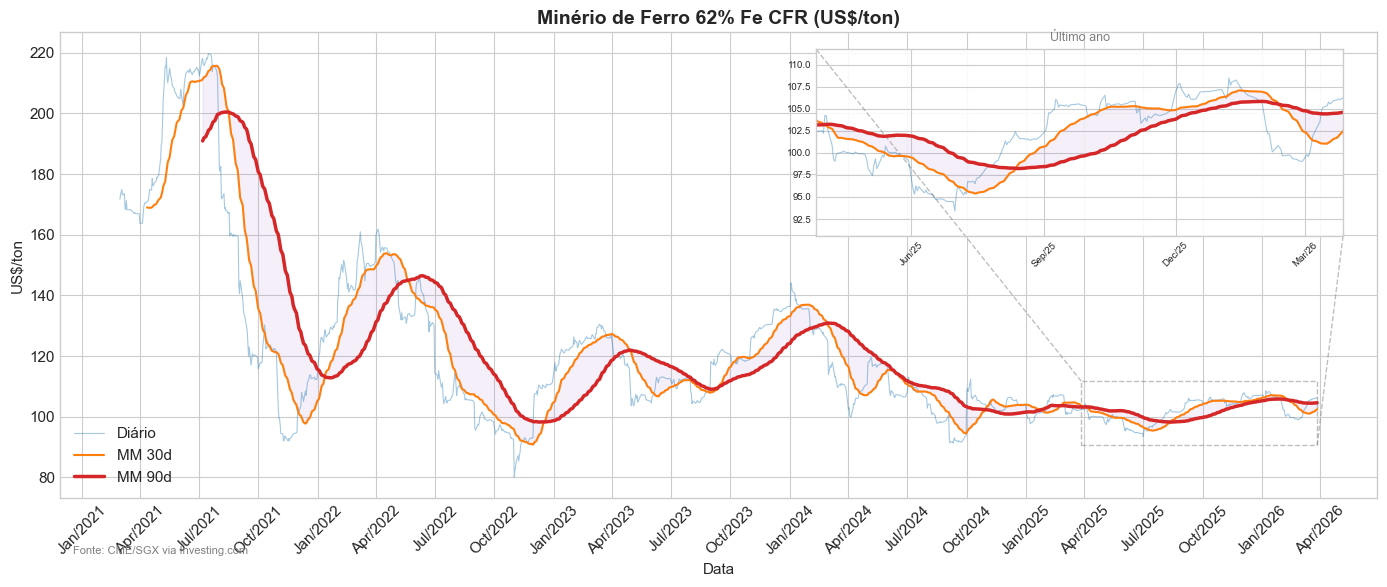

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
zoom_start = df.index.max() - ZOOM_PERIOD

s = df['iron_ore_62fe'].dropna()
r30 = s.rolling(30).mean()
r90 = s.rolling(90).mean()

ax.plot(s.index, s, alpha=0.4, linewidth=0.8, color='#1f77b4', label='Diário')
ax.plot(s.index, r30, linewidth=1.5, color='#ff7f0e', label='MM 30d')
ax.plot(s.index, r90, linewidth=2.5, color='#d62728', label='MM 90d')
ax.fill_between(s.index, r30, r90, alpha=0.1, color='#9467bd')

ax.set_title('Minério de Ferro 62% Fe CFR (US$/ton)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$/ton')
ax.set_xlabel('Data')
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: CME/SGX via Investing.com', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')

# Zoom inset - último ano
axins = inset_axes(ax, width='40%', height='40%', loc='upper right',
                   bbox_to_anchor=(-0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
sz = s[s.index >= zoom_start]
r30z = r30[r30.index >= zoom_start]
r90z = r90[r90.index >= zoom_start]
axins.plot(sz.index, sz, alpha=0.4, linewidth=0.8, color='#1f77b4')
axins.plot(r30z.index, r30z, linewidth=1.5, color='#ff7f0e')
axins.plot(r90z.index, r90z, linewidth=2.5, color='#d62728')
axins.fill_between(r30z.index, r30z, r90z, alpha=0.1, color='#9467bd')
axins.set_xlim(zoom_start, s.index.max())
if len(sz) > 0:
    axins.set_ylim(sz.min() * 0.97, sz.max() * 1.03)
axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axins.tick_params(axis='x', rotation=45, labelsize=7)
axins.tick_params(axis='y', labelsize=7)
axins.set_title('Último ano', fontsize=9, color='gray')
axins.patch.set_alpha(0.9)
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='0.5', ls='--', alpha=0.5)

plt.tight_layout()
save_fig(fig, 'iron_ore_detail')
plt.show()

## Lítio — Global X Lithium & Battery Tech ETF (LIT)
Proxy para o mercado de lítio. O ETF LIT acompanha mineradoras de lítio e produtores de baterias, sendo o benchmark mais acessível para exposição ao preço do lítio.

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/3535767844.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_lithium_lit.png


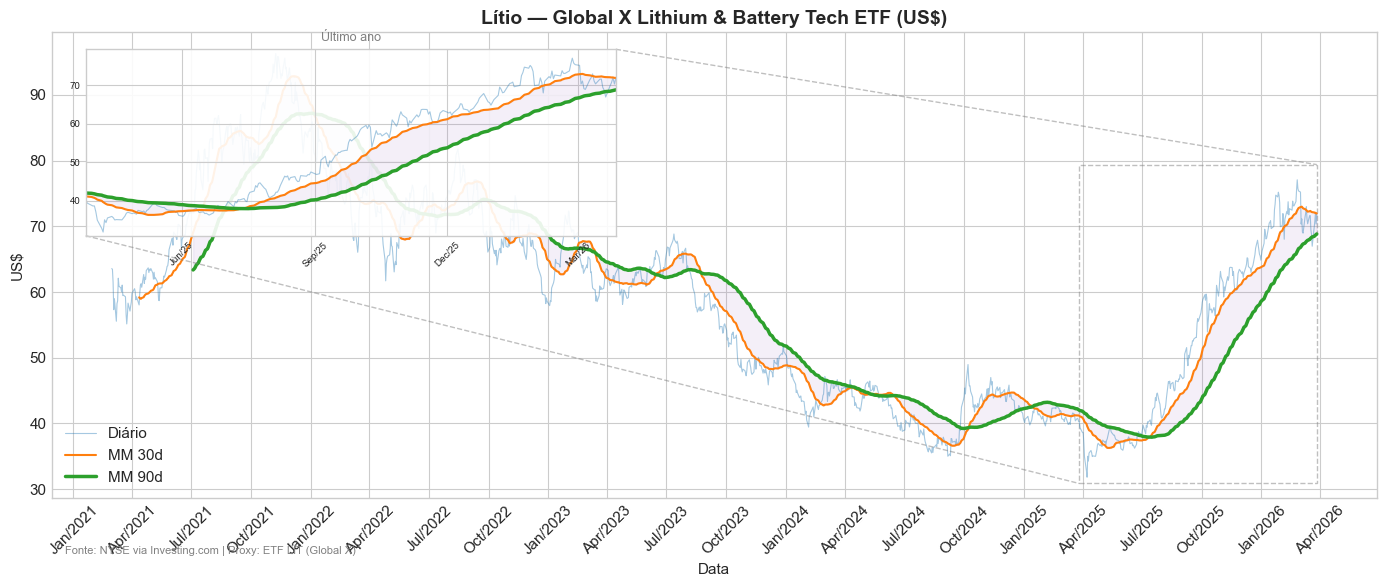

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
zoom_start = df.index.max() - ZOOM_PERIOD

s = df['lithium_lit'].dropna()
r30 = s.rolling(30).mean()
r90 = s.rolling(90).mean()

ax.plot(s.index, s, alpha=0.4, linewidth=0.8, color='#1f77b4', label='Diário')
ax.plot(s.index, r30, linewidth=1.5, color='#ff7f0e', label='MM 30d')
ax.plot(s.index, r90, linewidth=2.5, color='#2ca02c', label='MM 90d')
ax.fill_between(s.index, r30, r90, alpha=0.1, color='#9467bd')

ax.set_title('Lítio — Global X Lithium & Battery Tech ETF (US$)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$')
ax.set_xlabel('Data')
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: NYSE via Investing.com | Proxy: ETF LIT (Global X)', xy=(0.01, -0.12),
            xycoords='axes fraction', fontsize=8, color='gray')

# Zoom inset - último ano
axins = inset_axes(ax, width='40%', height='40%', loc='upper left',
                   bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
sz = s[s.index >= zoom_start]
r30z = r30[r30.index >= zoom_start]
r90z = r90[r90.index >= zoom_start]
axins.plot(sz.index, sz, alpha=0.4, linewidth=0.8, color='#1f77b4')
axins.plot(r30z.index, r30z, linewidth=1.5, color='#ff7f0e')
axins.plot(r90z.index, r90z, linewidth=2.5, color='#2ca02c')
axins.fill_between(r30z.index, r30z, r90z, alpha=0.1, color='#9467bd')
axins.set_xlim(zoom_start, s.index.max())
if len(sz) > 0:
    axins.set_ylim(sz.min() * 0.97, sz.max() * 1.03)
axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axins.tick_params(axis='x', rotation=45, labelsize=7)
axins.tick_params(axis='y', labelsize=7)
axins.set_title('Último ano', fontsize=9, color='gray')
axins.patch.set_alpha(0.9)
mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)

plt.tight_layout()
save_fig(fig, 'lithium_lit')
plt.show()

## Energia e Industriais
Carvão Newcastle, Aço HRC China, Urânio, Lítio (LIT ETF) e comparação normalizada.

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/1676351684.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_energy_industrial.png


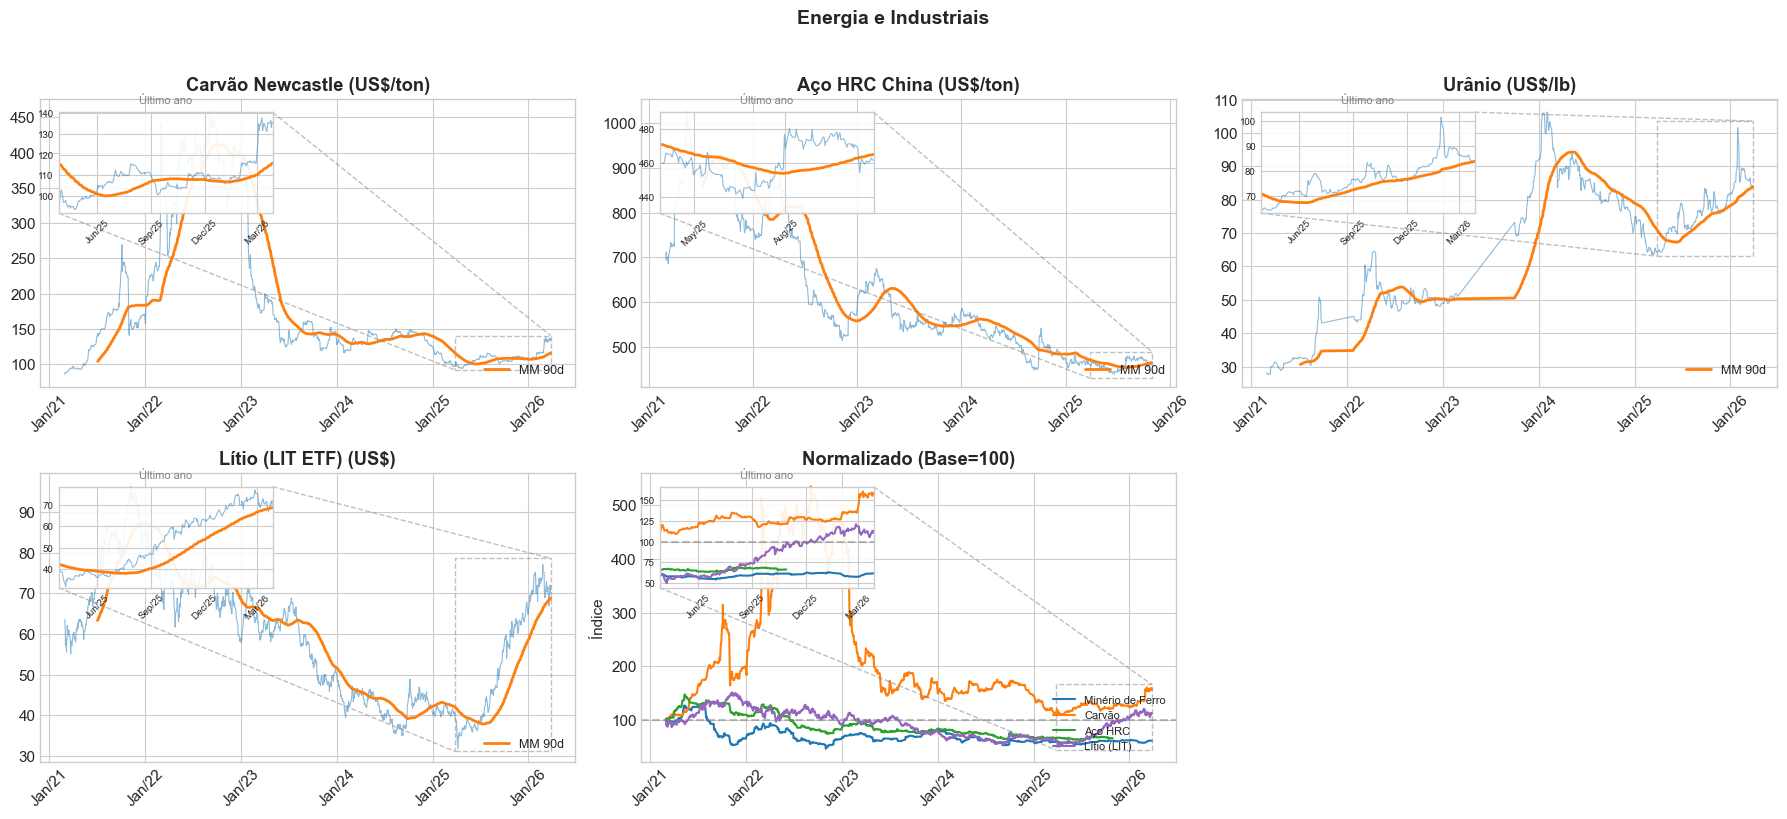

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
zoom_start = df.index.max() - ZOOM_PERIOD

energy_cols = [
    ('coal_newcastle', 'Carvão Newcastle', 'US$/ton'),
    ('steel_hrc_china', 'Aço HRC China', 'US$/ton'),
    ('uranium', 'Urânio', 'US$/lb'),
    ('lithium_lit', 'Lítio (LIT ETF)', 'US$'),
]
for ax, (col, label, unit) in zip(axes.flat[:4], energy_cols):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    s = df[col].dropna()
    r90 = s.rolling(90).mean()
    ax.plot(s.index, s, alpha=0.5, linewidth=0.8, color='#1f77b4')
    ax.plot(s.index, r90, linewidth=2, color='#ff7f0e', label='MM 90d')
    ax.set_title(f'{label} ({unit})', fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)
    # Zoom inset - último ano
    axins = inset_axes(ax, width='40%', height='35%', loc='upper left',
                       bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
    sz = s[s.index >= zoom_start]
    rz = r90[r90.index >= zoom_start]
    axins.plot(sz.index, sz, alpha=0.5, linewidth=0.8, color='#1f77b4')
    axins.plot(rz.index, rz, linewidth=2, color='#ff7f0e')
    axins.set_xlim(zoom_start, s.index.max())
    if len(sz) > 0:
        axins.set_ylim(sz.min() * 0.98, sz.max() * 1.02)
    axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axins.tick_params(axis='x', rotation=45, labelsize=7)
    axins.tick_params(axis='y', labelsize=7)
    axins.set_title('Último ano', fontsize=8, color='gray')
    axins.patch.set_alpha(0.9)
    mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)

# Comparação normalizada
ax = axes[1, 1]
norm_cols = [('iron_ore_62fe', 'Minério de Ferro', '#1f77b4'),
             ('coal_newcastle', 'Carvão', '#ff7f0e'),
             ('steel_hrc_china', 'Aço HRC', '#2ca02c'),
             ('lithium_lit', 'Lítio (LIT)', '#9467bd')]
for col, label, color in norm_cols:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    if len(s) > 0:
        normalized = (s / s.iloc[0]) * 100
        ax.plot(normalized.index, normalized, label=label, color=color, linewidth=1.5)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Normalizado (Base=100)', fontweight='bold')
ax.set_ylabel('Índice')
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Zoom inset para comparação normalizada
axins = inset_axes(ax, width='40%', height='35%', loc='upper left',
                   bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
for col, label, color in norm_cols:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    if len(s) > 0:
        normalized = (s / s.iloc[0]) * 100
        nz = normalized[normalized.index >= zoom_start]
        axins.plot(nz.index, nz, color=color, linewidth=1.5)
axins.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
axins.set_xlim(zoom_start, df.index.max())
axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axins.tick_params(axis='x', rotation=45, labelsize=7)
axins.tick_params(axis='y', labelsize=7)
axins.set_title('Último ano', fontsize=8, color='gray')
axins.patch.set_alpha(0.9)
mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)

# Hide unused subplot
axes[1, 2].set_visible(False)

fig.suptitle('Energia e Industriais', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'energy_industrial')
plt.show()

## Desempenho Relativo - Todas as Commodities (Base 100)

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/689763623.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_relative_performance.png


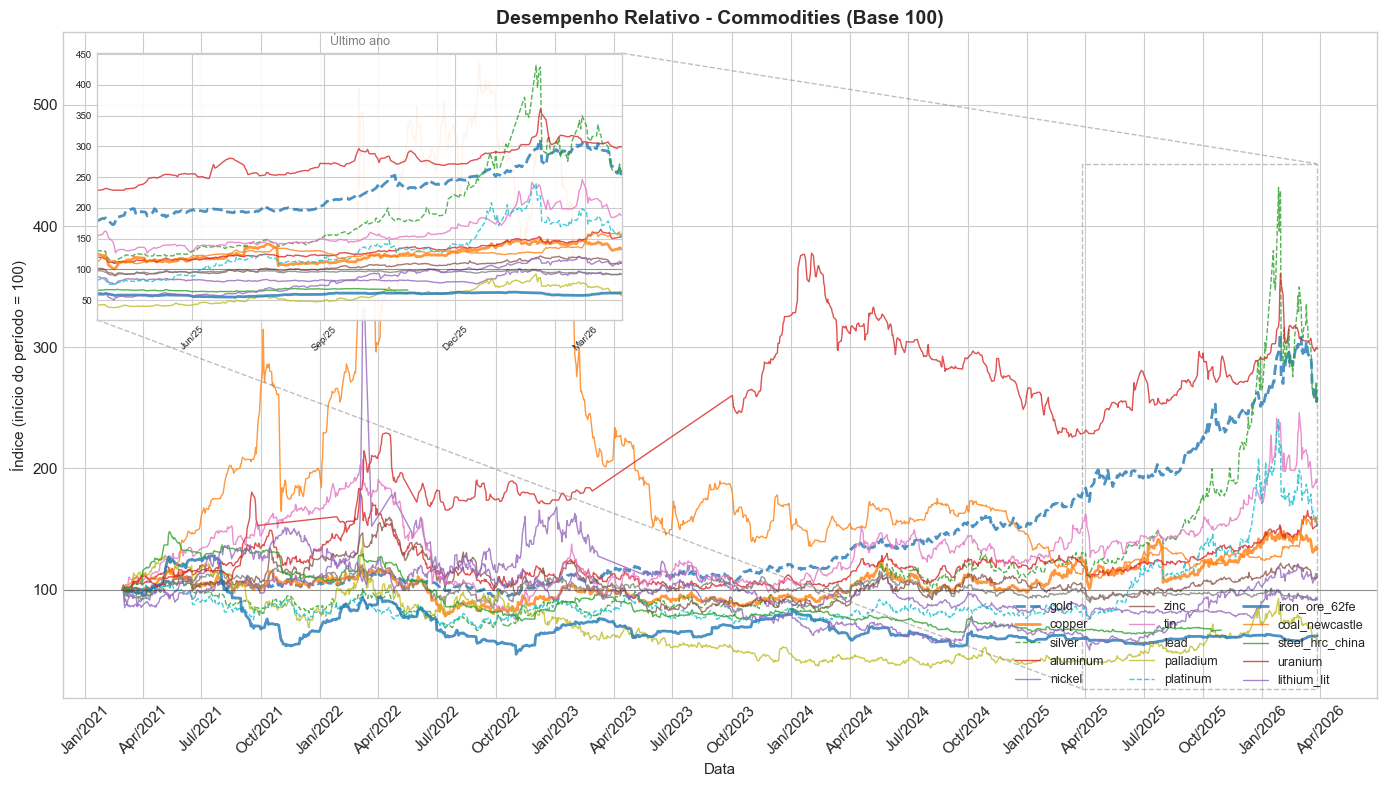

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
zoom_start = df.index.max() - ZOOM_PERIOD

precious_cols = ['gold', 'silver', 'platinum']
industrial_cols = ['copper', 'aluminum', 'nickel', 'zinc', 'iron_ore_62fe', 'coal_newcastle']

for col in df.columns:
    s = df[col].dropna()
    if len(s) < 10:
        continue
    normalized = (s / s.iloc[0]) * 100
    ls = '--' if col in precious_cols else '-'
    lw = 2 if col in ['gold', 'iron_ore_62fe', 'copper'] else 1
    ax.plot(normalized.index, normalized, label=col, linestyle=ls, linewidth=lw, alpha=0.8)

ax.axhline(y=100, color='black', linestyle='-', alpha=0.3, linewidth=0.8)
ax.set_title('Desempenho Relativo - Commodities (Base 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Índice (início do período = 100)')
ax.set_xlabel('Data')
ax.legend(loc='lower right', ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

# Zoom inset - último ano
axins = inset_axes(ax, width='40%', height='40%', loc='upper left',
                   bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
for col in df.columns:
    s = df[col].dropna()
    if len(s) < 10:
        continue
    normalized = (s / s.iloc[0]) * 100
    nz = normalized[normalized.index >= zoom_start]
    ls = '--' if col in precious_cols else '-'
    lw = 2 if col in ['gold', 'iron_ore_62fe', 'copper'] else 1
    axins.plot(nz.index, nz, linestyle=ls, linewidth=lw, alpha=0.8)
axins.axhline(y=100, color='black', linestyle='-', alpha=0.3, linewidth=0.8)
axins.set_xlim(zoom_start, df.index.max())
axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axins.tick_params(axis='x', rotation=45, labelsize=7)
axins.tick_params(axis='y', labelsize=7)
axins.set_title('Último ano', fontsize=9, color='gray')
axins.patch.set_alpha(0.9)
mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)

plt.tight_layout()
save_fig(fig, 'relative_performance')
plt.show()

## Correlação dos Retornos Diários

  Saved: ../figures/investpy/investpy_correlation.png


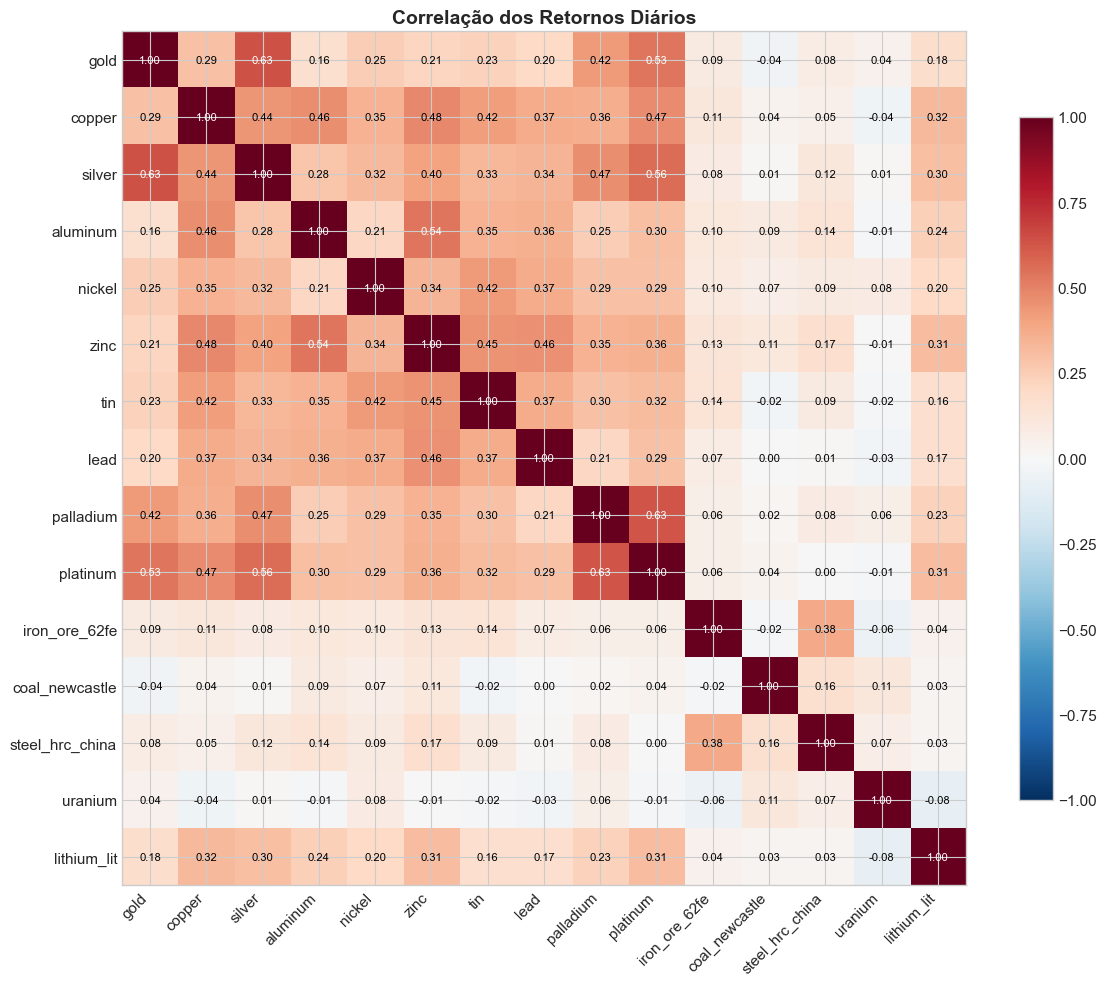

In [9]:
returns = df.pct_change().dropna()
corr = returns.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlação dos Retornos Diários', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'correlation')
plt.show()

## Volatilidade - Desvio-Padrão 30 Dias dos Retornos

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/1310720243.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_volatility.png


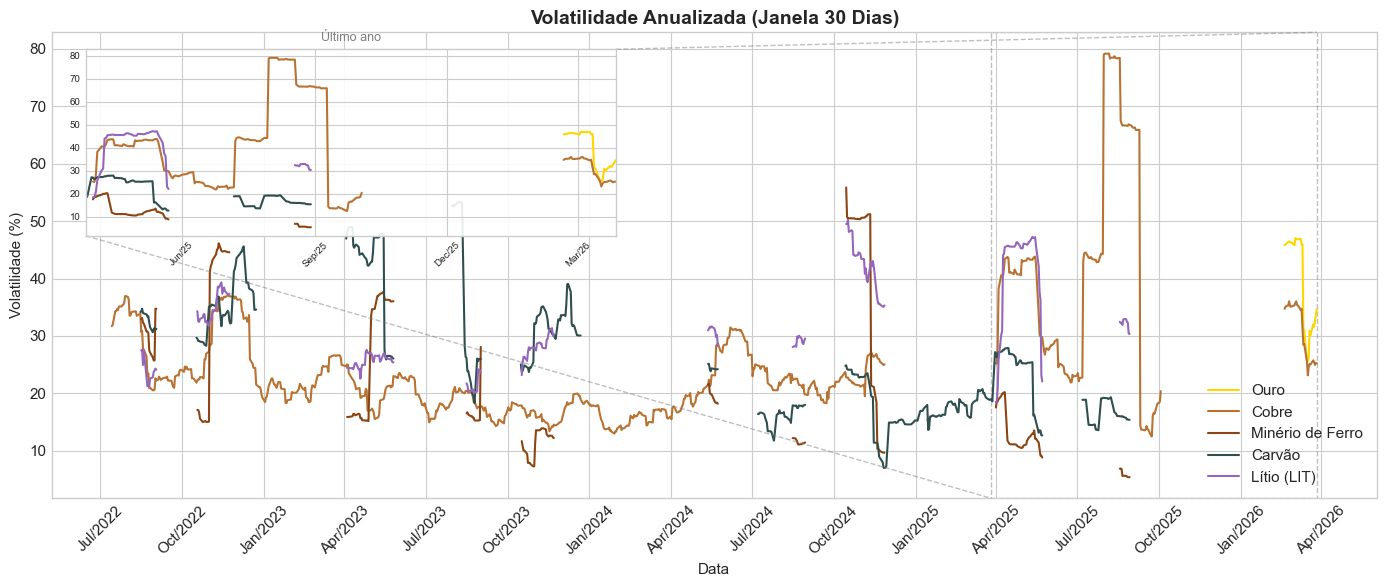

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
zoom_start = df.index.max() - ZOOM_PERIOD

key_commodities = [('gold', 'Ouro', '#FFD700'), ('copper', 'Cobre', '#B87333'),
                   ('iron_ore_62fe', 'Minério de Ferro', '#8B4513'),
                   ('coal_newcastle', 'Carvão', '#2F4F4F'),
                   ('lithium_lit', 'Lítio (LIT)', '#9467bd')]

for col, label, color in key_commodities:
    if col not in df.columns:
        continue
    vol = df[col].pct_change().rolling(30).std() * np.sqrt(252) * 100
    ax.plot(vol.index, vol, label=label, color=color, linewidth=1.5)

ax.set_title('Volatilidade Anualizada (Janela 30 Dias)', fontsize=14, fontweight='bold')
ax.set_ylabel('Volatilidade (%)')
ax.set_xlabel('Data')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

# Zoom inset - último ano
axins = inset_axes(ax, width='40%', height='40%', loc='upper left',
                   bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
for col, label, color in key_commodities:
    if col not in df.columns:
        continue
    vol = df[col].pct_change().rolling(30).std() * np.sqrt(252) * 100
    vz = vol[vol.index >= zoom_start]
    axins.plot(vz.index, vz, color=color, linewidth=1.5)
axins.set_xlim(zoom_start, df.index.max())
axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axins.tick_params(axis='x', rotation=45, labelsize=7)
axins.tick_params(axis='y', labelsize=7)
axins.set_title('Último ano', fontsize=9, color='gray')
axins.patch.set_alpha(0.9)
mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)

plt.tight_layout()
save_fig(fig, 'volatility')
plt.show()

## Painel Resumo - Principais Commodities

/var/folders/gs/8jzvxtq963j3ltcf_f6xm35h0000gp/T/ipykernel_90426/3685775418.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../figures/investpy/investpy_dashboard.png


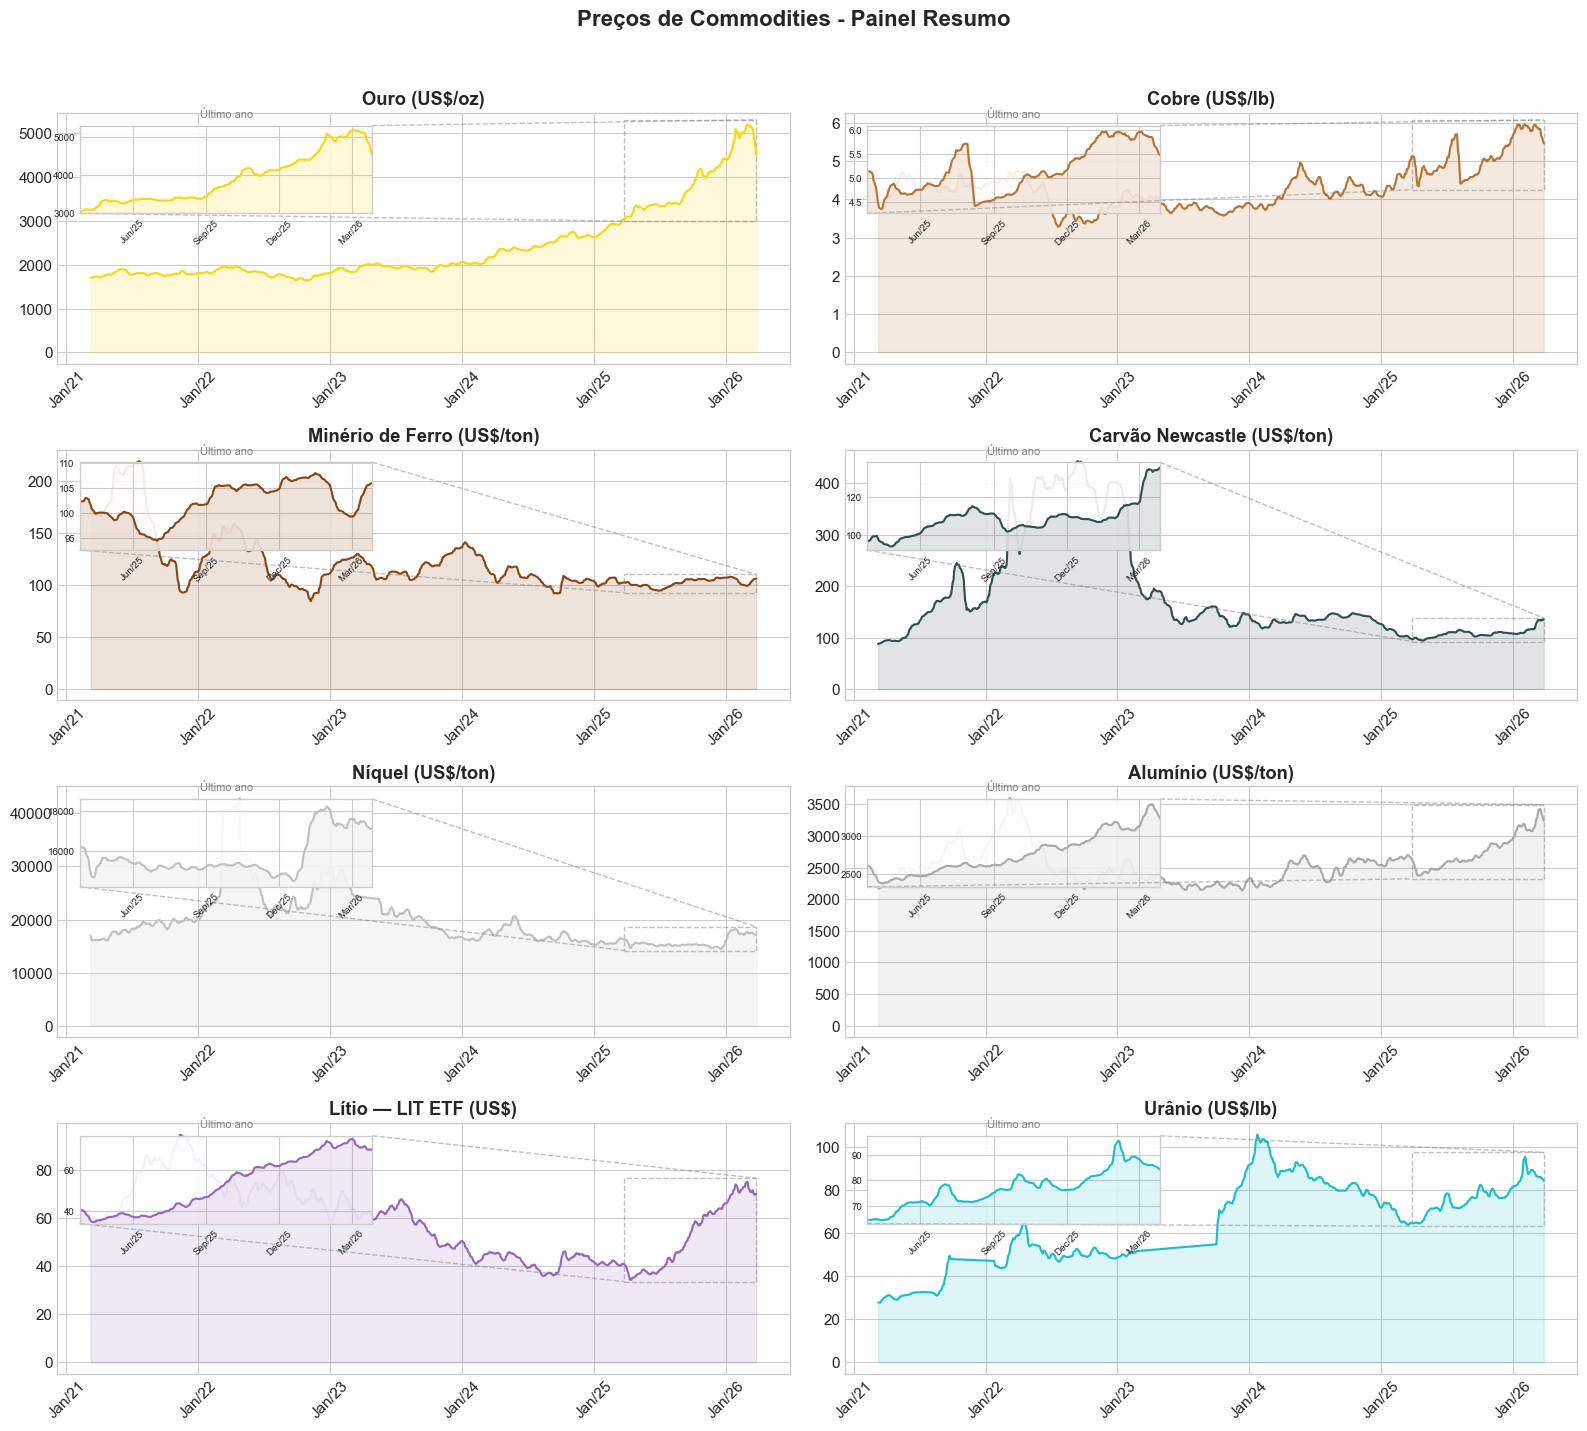

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
zoom_start = df.index.max() - ZOOM_PERIOD

dashboard = [
    ('gold', 'Ouro (US$/oz)', '#FFD700'),
    ('copper', 'Cobre (US$/lb)', '#B87333'),
    ('iron_ore_62fe', 'Minério de Ferro (US$/ton)', '#8B4513'),
    ('coal_newcastle', 'Carvão Newcastle (US$/ton)', '#2F4F4F'),
    ('nickel', 'Níquel (US$/ton)', '#C0C0C0'),
    ('aluminum', 'Alumínio (US$/ton)', '#A9A9A9'),
    ('lithium_lit', 'Lítio — LIT ETF (US$)', '#9467bd'),
    ('uranium', 'Urânio (US$/lb)', '#17becf'),
]

for ax, (col, title, color) in zip(axes.flat, dashboard):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    s = df[col].dropna()
    r7 = s.rolling(7).mean()
    ax.plot(r7.index, r7, color=color, linewidth=1.5)
    ax.fill_between(r7.index, r7, alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)
    # Zoom inset - último ano
    axins = inset_axes(ax, width='40%', height='35%', loc='upper left',
                       bbox_to_anchor=(0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)
    r7z = r7[r7.index >= zoom_start].dropna()
    axins.plot(r7z.index, r7z, color=color, linewidth=1.5)
    axins.fill_between(r7z.index, r7z, alpha=0.15, color=color)
    axins.set_xlim(zoom_start, s.index.max())
    if len(r7z) > 0:
        axins.set_ylim(r7z.min() * 0.98, r7z.max() * 1.02)
    axins.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    axins.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axins.tick_params(axis='x', rotation=45, labelsize=7)
    axins.tick_params(axis='y', labelsize=7)
    axins.set_title('Último ano', fontsize=8, color='gray')
    axins.patch.set_alpha(0.9)
    mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.5', ls='--', alpha=0.5)

fig.suptitle('Preços de Commodities - Painel Resumo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'dashboard')
plt.show()